# LeetCode #1283: Find the Smallest Divisor Given a Threshold

https://leetcode.com/problems/find-the-smallest-divisor-given-a-threshold/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (try every divisor)** | $O(n \cdot \max(\text{nums}))$ | $O(1)$ |
| **Optimal: Binary Search on Divisor ★** | $O(n \log m)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (try every divisor)
Try every integer from 1 to $\max(\text{nums})$; for each compute $\sum \lceil \text{nums}[i] / d \rceil$ and return the first $d$ where the sum $\le \text{threshold}$. $O(n \cdot m)$ where $m = \max \le 10^6$ — up to $10^{11}$ operations at max constraints.

### Optimal: Binary Search on Divisor ★
As divisor $d$ increases, the sum $\sum \lceil \text{nums}[i] / d \rceil$ decreases monotonically. Binary search for the smallest $d$ in $[1, \max(\text{nums})]$ where the sum $\le \text{threshold}$. Each check is $O(n)$; with $O(\log m)$ steps the total is $O(n \log m)$.

**Why this is better than Brute Force:** Monotone decrease in sum with increasing $d$ enables binary search, cutting the $O(m)$ linear scan to $O(\log m)$.

**Constraints:**
* $1 \le \text{nums.length} \le 5 \times 10^4$
* $1 \le \text{nums}[i] \le 10^6$
* $\text{nums.length} \le \text{threshold} \le 10^6$


## Solutions

### C#

In [ ]:
public int SmallestDivisor(int[] nums, int threshold) {
    int lo = 1, hi = nums.Max();
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Compute ceiling-division sum: ⌈nums[i]/mid⌉ = (nums[i]+mid-1)/mid
        int sum = nums.Sum(n => (n + mid - 1) / mid);
        // If sum within threshold, try smaller divisor
        if (sum <= threshold) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
import math

def smallest_divisor(nums: list[int], threshold: int) -> int:
    lo, hi = 1, max(nums)
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Compute ceiling-division sum: ⌈nums[i]/mid⌉
        total = sum(math.ceil(n / mid) for n in nums)
        # If sum within threshold, try smaller divisor
        if total <= threshold:
            hi = mid
        else:
            lo = mid + 1
    return lo


### Go

In [ ]:
func smallestDivisor(nums []int, threshold int) int {
    lo, hi := 1, slices.Max(nums)
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Compute ceiling-division sum: ⌈nums[i]/mid⌉ = (nums[i]+mid-1)/mid
        sum := 0
        for _, n := range nums { sum += (n + mid - 1) / mid }
        // If sum within threshold, try smaller divisor
        if sum <= threshold { hi = mid } else { lo = mid + 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn smallest_divisor(nums: Vec<i32>, threshold: i32) -> i32 {
    let (mut lo, mut hi) = (1i32, *nums.iter().max().unwrap());
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Compute ceiling-division sum: ⌈nums[i]/mid⌉ = (nums[i]+mid-1)/mid
        let sum: i32 = nums.iter().map(|&n| (n + mid - 1) / mid).sum();
        // If sum within threshold, try smaller divisor
        if sum <= threshold { hi = mid; } else { lo = mid + 1; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 2, 5, 9], threshold = 6
lo=1, hi=9. mid=5: ⌈1/5⌉+⌈2/5⌉+⌈5/5⌉+⌈9/5⌉=1+1+1+2=5≤6→hi=5. mid=3: ⌈1/3⌉+⌈2/3⌉+⌈5/3⌉+⌈9/3⌉=1+1+2+3=7>6→lo=4. mid=4: 1+1+2+3=7? No: ⌈9/4⌉=3, sum=1+1+2+3=7>6→lo=5=hi. Answer: 5.

**2. Slightly Complex**
**Input:** nums = [2, 3, 5, 7, 11], threshold = 11
At d=1: sum=28>11. At d=3: ⌈2/3⌉+⌈3/3⌉+⌈5/3⌉+⌈7/3⌉+⌈11/3⌉=1+1+2+3+4=11≤11→hi=3. At d=2: 1+2+3+4+6=16>11→lo=3=hi. Answer: 3.

**3. Edge Case: Time Factor**
**Input:** nums = [10^6, 10^6, ..., 10^6] (50000 elements), threshold = 50000
At d=10^6: each ⌈10^6/10^6⌉=1, sum=50000=threshold→hi=10^6. Binary search: log₂(10^6)≈20 iterations × 50000 elements = 10^6 ops. Converges to d=10^6.

**4. Edge Case: Space Factor**
**Input:** nums = [1, 10^6], threshold = 2
At d=10^6: ⌈1/10^6⌉+⌈10^6/10^6⌉=1+1=2≤2→hi=10^6. At d=500000: 1+2=3>2→lo=500001. Converges to 10^6. Variables: lo, hi, mid, sum, n — 5 integers = O(1) space.

**5. Almost-Impossible but Plausible**
**Input:** nums = [1, 1, 1, 1000000], threshold = 4
At d=1000000: ⌈1/10^6⌉×3+⌈10^6/10^6⌉=1+1+1+1=4≤4→hi=10^6. At d=500000: 1+1+1+2=5>4→lo=500001. At d=750000: 1+1+1+2=5>4→lo still rises. At d=999999: ⌈10^6/999999⌉=2, sum=1+1+1+2=5>4→lo=10^6=hi. Answer: 10^6. The million-weight element forces d to its own value before sum drops to 4.


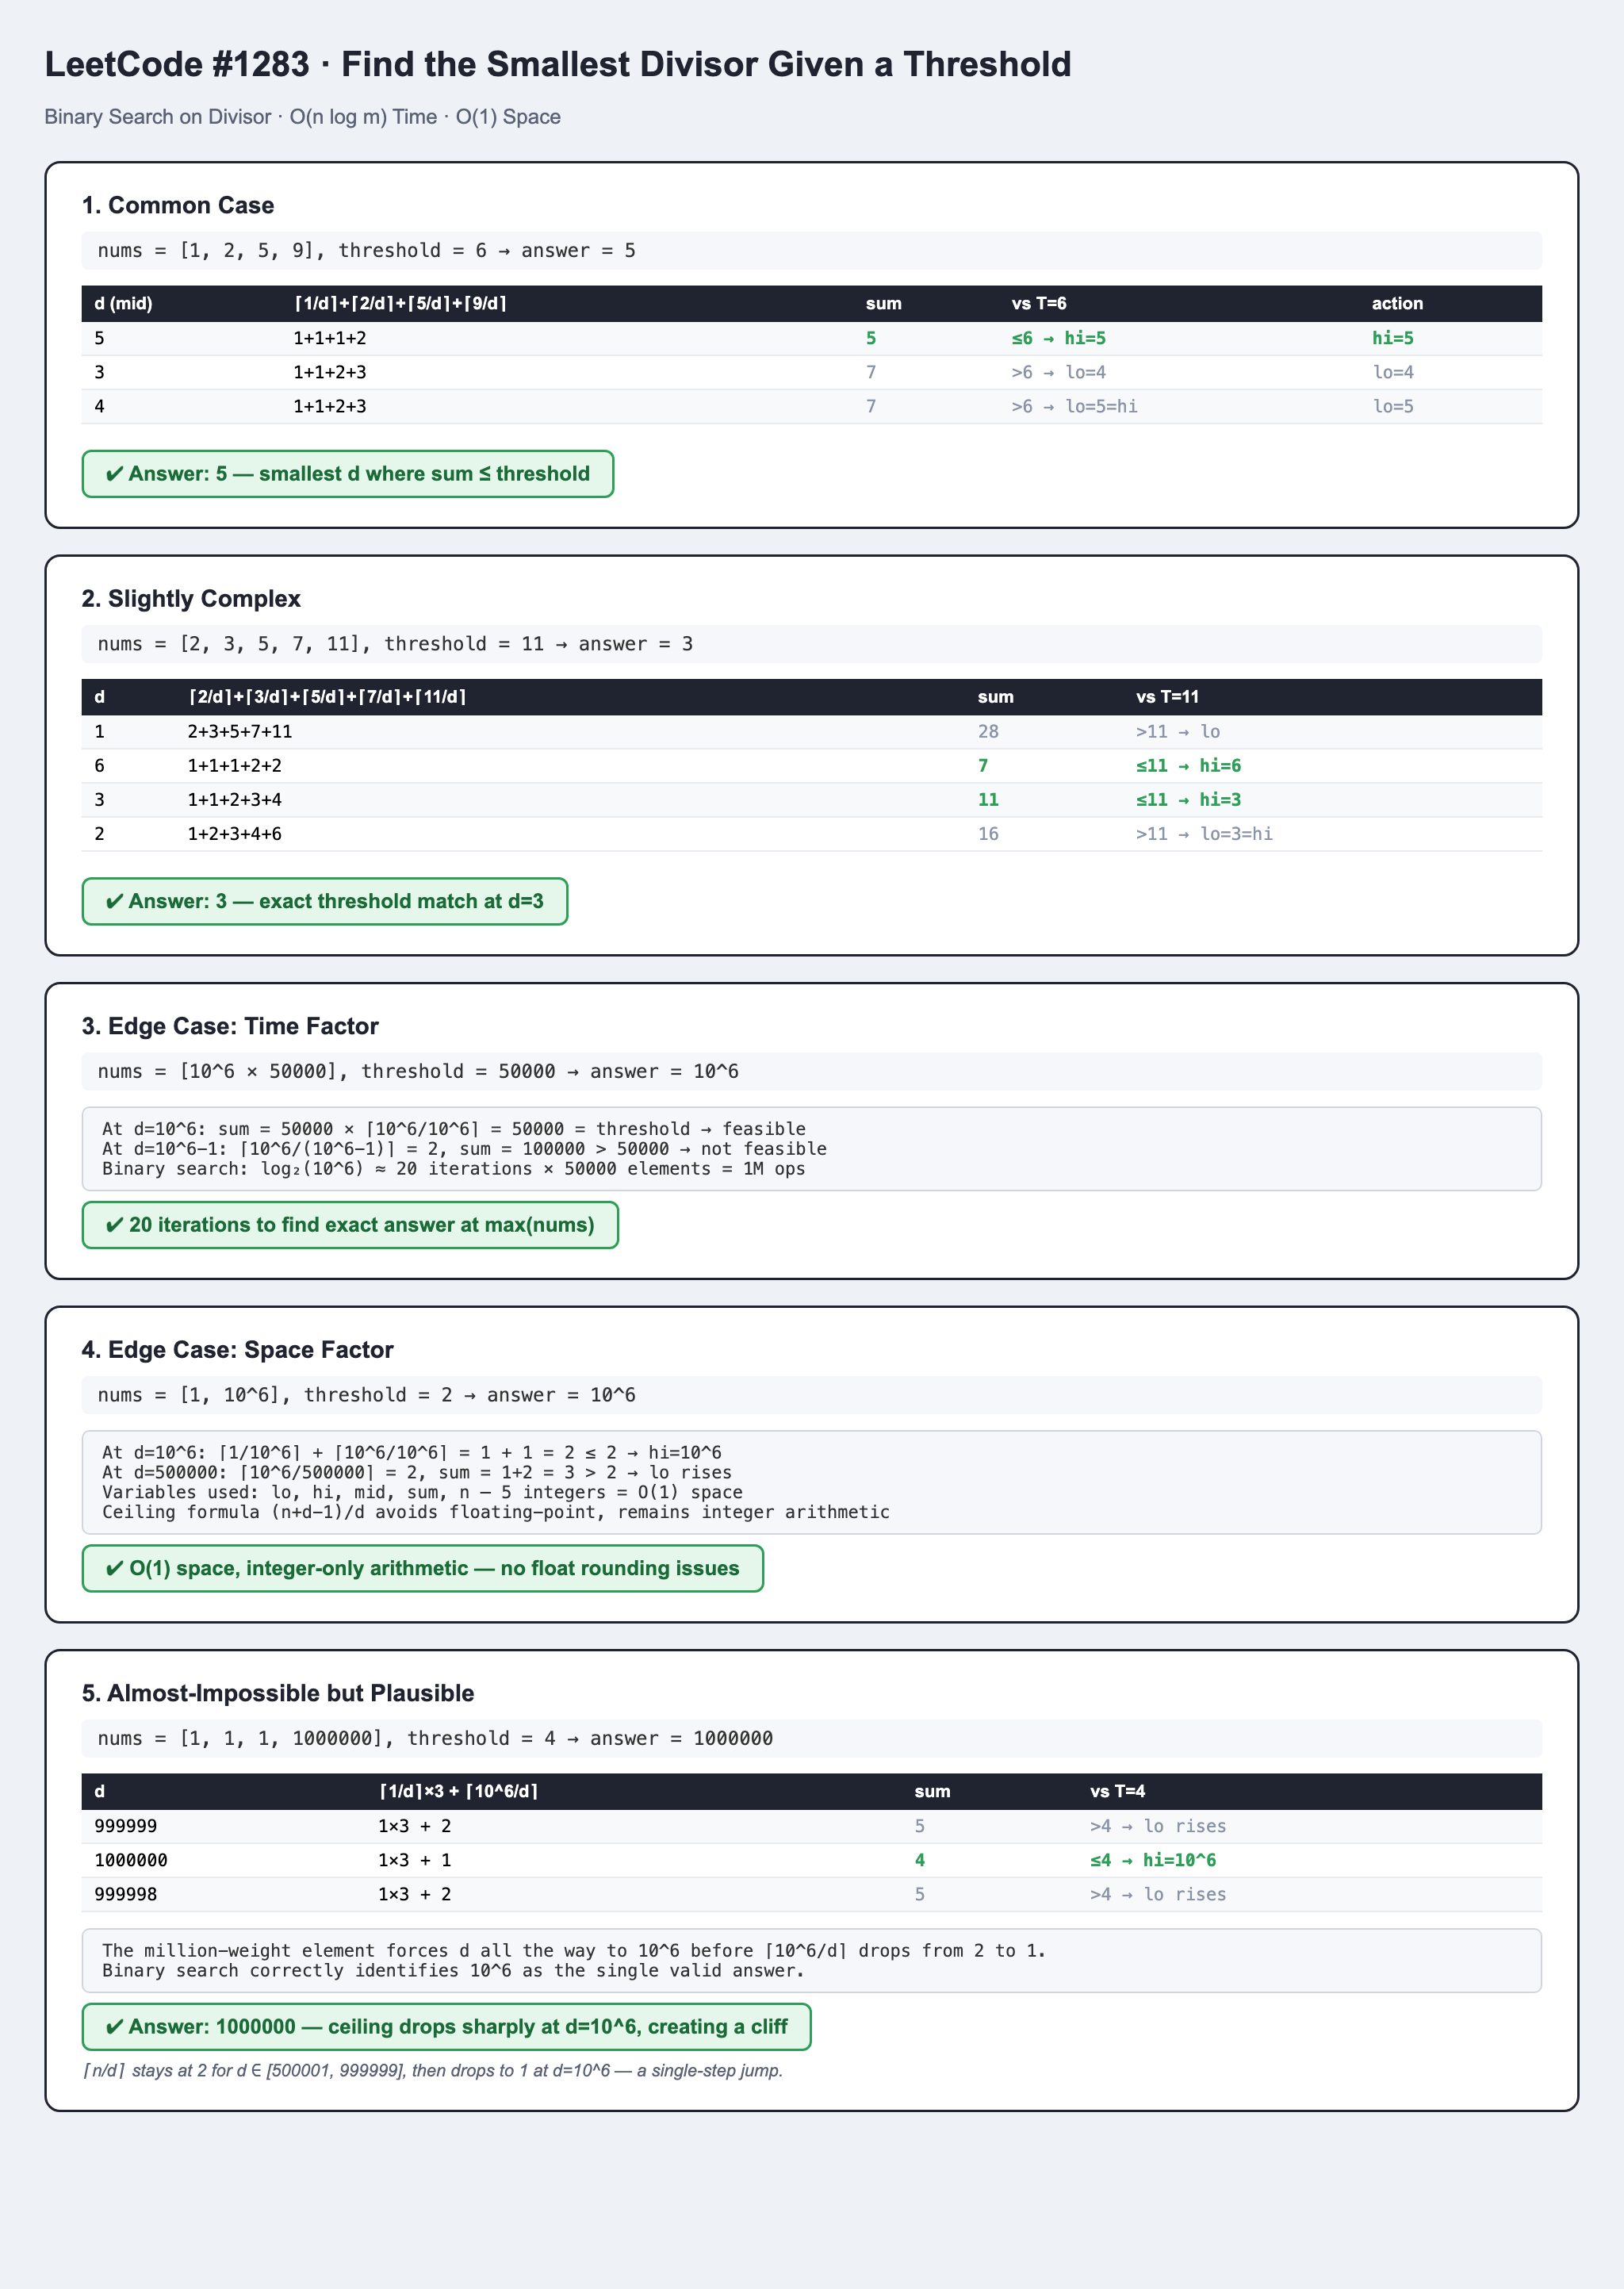